In [1]:
import numpy as np
import xarray as xr
from eofs.xarray import Eof
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import xclimate as xclim

In [2]:
time_slice = slice("1950-01", "2014-12")
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
variables = [
    "EFLX_LH_TOT_month_1",
    "FCTR_month_1",
    "FCEV_month_1",
    "FGEV_month_1",
    "TLAI_month_1",
    "FSH_month_1",
    "TSA_month_1",
]

In [3]:
grid = xclim.load_fhist_ppe_grid()

fhist = {}
for v in variables:
    print(v)
    name = "_".join(v.split("_")[:-2])
    fhist[v] = xclim.load_fhist(v, keep_var_only=True)[name].sel(time=time_slice).reindex_like(grid, method="nearest", tolerance=1e-3)
    fhist[v] = fhist[v].where(grid.LANDFRAC > 0).chunk({'time': -1})

EFLX_LH_TOT_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
FCTR_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
FCEV_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
FGEV_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
TLAI_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
FSH_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
TSA_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


In [4]:
gc = dict(lat=45, lon=270, method='nearest')

IndexError: Index 27 is out of bounds for axis 0 with size 27

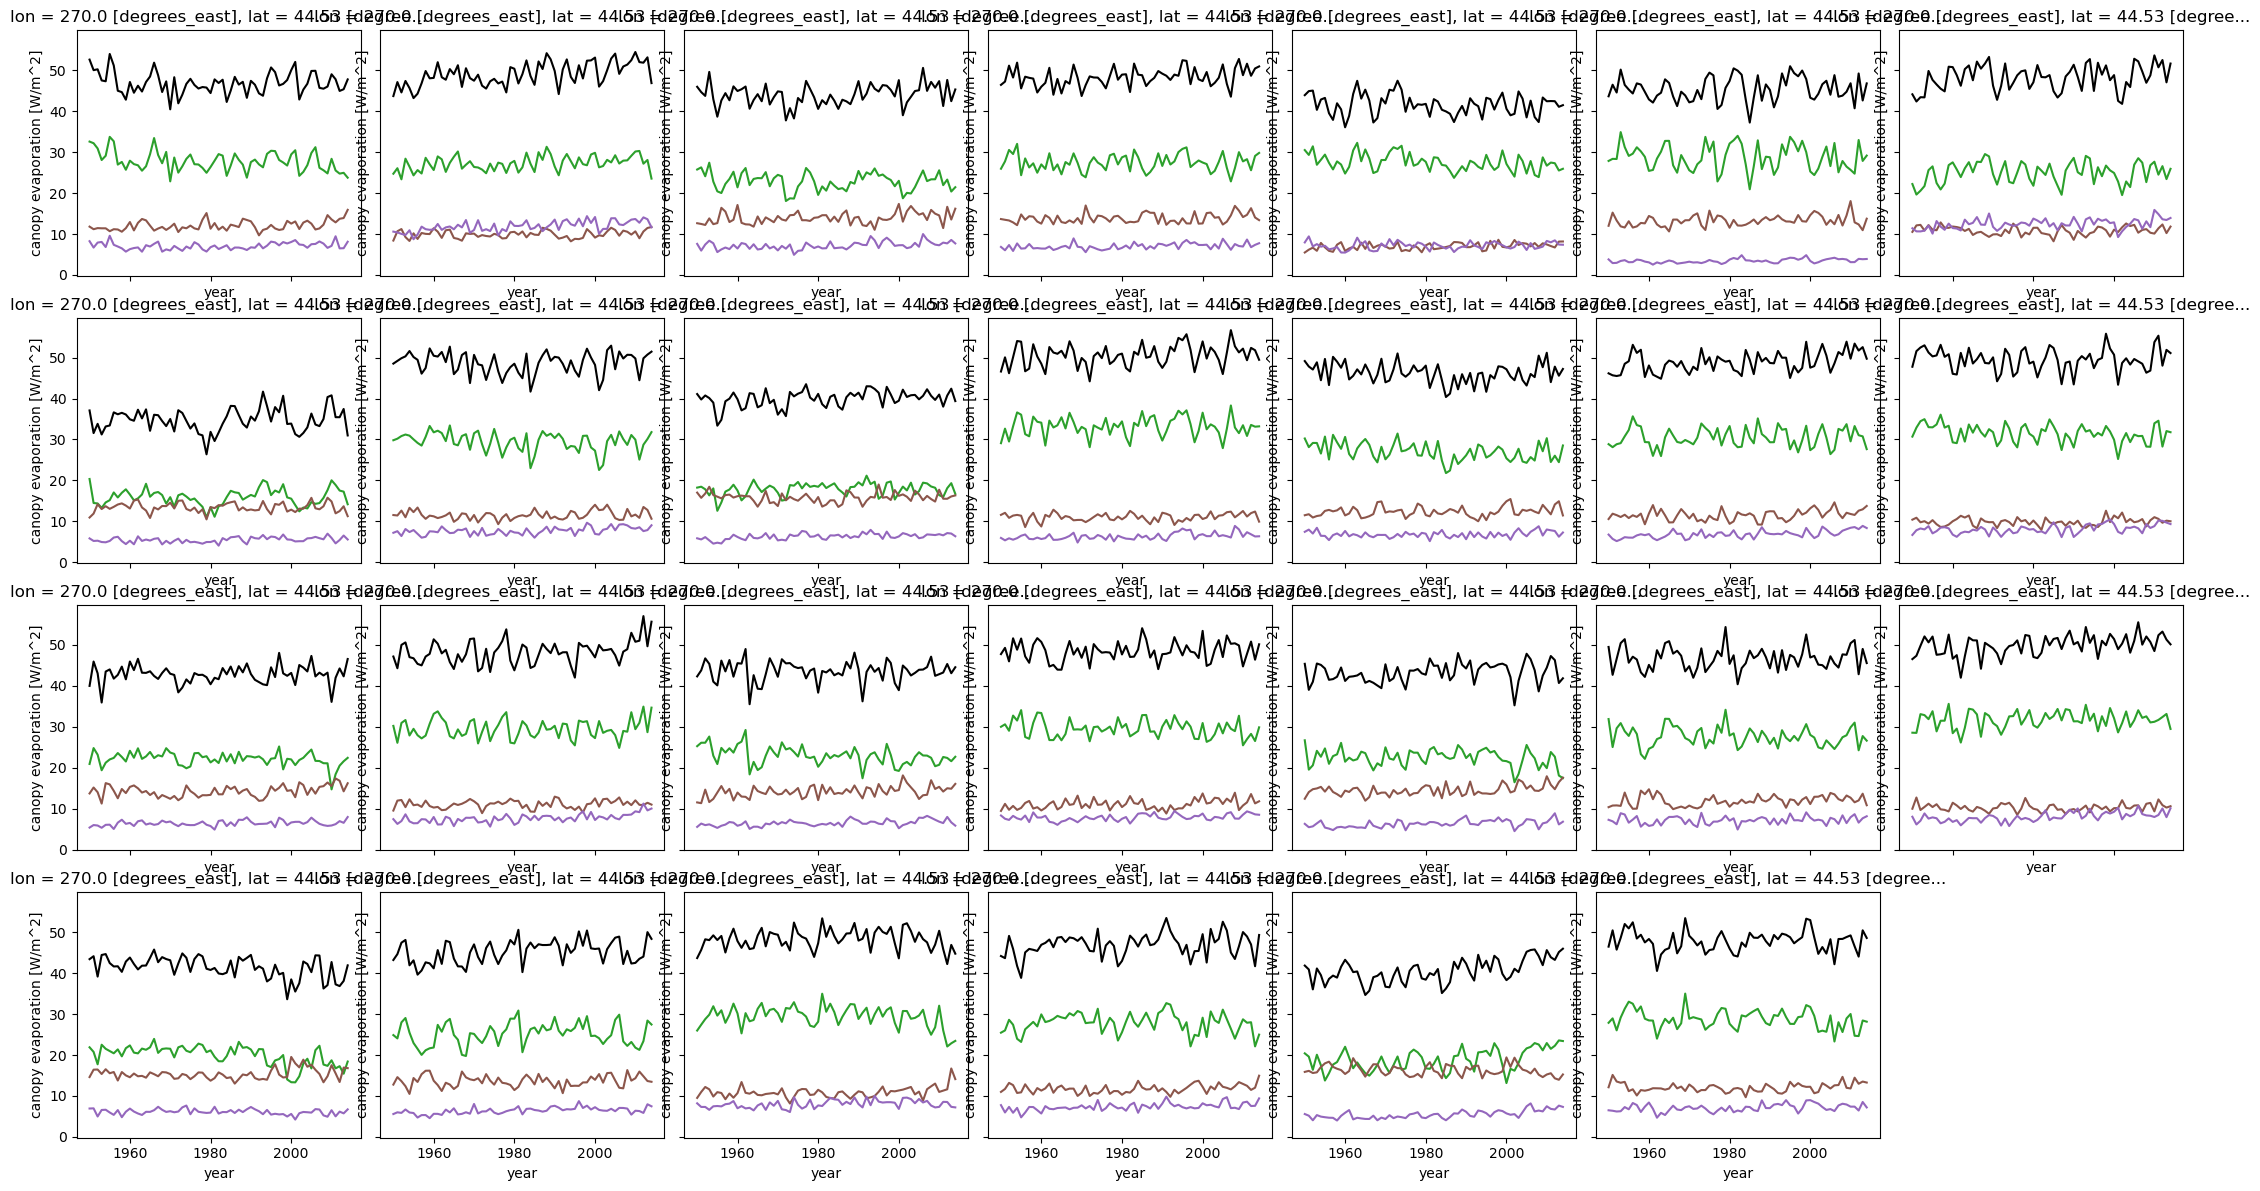

In [5]:
fg = fhist['EFLX_LH_TOT_month_1'].sel(**gc).groupby('time.year').mean().plot(col='member', col_wrap=7, color='k')

for i, ax in enumerate(fg.axs.ravel()):
    fhist['FCTR_month_1'].sel(**gc).isel(member=i).groupby('time.year').mean().plot(ax=ax, color='tab:green')
    fhist['FGEV_month_1'].sel(**gc).isel(member=i).groupby('time.year').mean().plot(ax=ax, color='tab:brown')
    fhist['FCEV_month_1'].sel(**gc).isel(member=i).groupby('time.year').mean().plot(ax=ax, color='tab:purple')

In [ ]:
fhist_diff = {}
fhist_tavg = {}
fhist_diff_tavg = {}
for v in variables:
    fhist_diff[v] = fhist[v].sel(member=slice(1, None)) - fhist[v].sel(member=0)
    fhist_tavg[v] = fhist[v].sel(time=slice("1995-01", "2014-12")).mean(dim="time").compute()
    fhist_diff_tavg[v] = fhist_diff[v].sel(time=slice("1995-01", "2014-12")).mean(dim="time").compute()

In [20]:
from collections import namedtuple
EOFResult = namedtuple(
    "EOFResult",
    [
        "eofs",
        "eofs_2sigma",
        "varfrac",
        "eig",
        "eig_err",
        "pcs",
        "solver",
        "reconstructed",
    ]
)

fhist_diff_tavg_eof = {}
fhist_tavg_eof = {}
for v in variables:
    print(v)

    x = fhist_diff_tavg[v].rename({"member": "time"})
    x["time"] = np.arange("1000-01-01", "1000-01-27", dtype="datetime64")
    dmx = x - x.mean(dim="time")

    solver = Eof(x, weights=grid.LANDAREA)
    eofs = solver.eofs()
    pcs = solver.pcs()

    std_pcs = pcs.std(dim="time")
    # reindex_weights = grid.LANDAREA.reindex_like(eofs, method="nearest")
    eofs_2sigma = xr.DataArray(
        2 * eofs.values * std_pcs.values[:, None, None] / grid.LANDAREA.values[None, :, :],
        dims=eofs.dims,
        coords=eofs.coords,
        attrs=eofs.attrs
    )

    fhist_diff_tavg_eof[v] = EOFResult(
        eofs=solver.eofs(eofscaling=0),
        eofs_2sigma=eofs_2sigma,
        varfrac=solver.varianceFraction(),
        eig=solver.eigenvalues(),
        eig_err=solver.northTest(vfscaled=True),
        pcs=solver.pcs(pcscaling=0),
        solver=solver,
        reconstructed=solver.reconstructedField(1),
    )



    x = fhist_tavg[v].rename({"member": "time"})
    x["time"] = np.arange("1000-01-01", "1000-01-28", dtype="datetime64")
    dmx = x - x.mean(dim="time")

    solver = Eof(x, weights=grid.LANDAREA)
    eofs = solver.eofs()
    pcs = solver.pcs()

    std_pcs = pcs.std(dim="time")
    # reindex_weights = grid.LANDAREA.reindex_like(eofs, method="nearest")
    eofs_2sigma = xr.DataArray(
        2 * eofs.values * std_pcs.values[:, None, None] / grid.LANDAREA.values[None, :, :],
        dims=eofs.dims,
        coords=eofs.coords,
        attrs=eofs.attrs
    )

    fhist_tavg_eof[v] = EOFResult(
        eofs=solver.eofs(eofscaling=0),
        eofs_2sigma=eofs_2sigma,
        varfrac=solver.varianceFraction(),
        eig=solver.eigenvalues(),
        eig_err=solver.northTest(vfscaled=True),
        pcs=solver.pcs(pcscaling=0),
        solver=solver,
        reconstructed=solver.reconstructedField(1),
    )

EFLX_LH_TOT_month_1
FCTR_month_1
FCEV_month_1
FGEV_month_1
TLAI_month_1
FSH_month_1
TSA_month_1


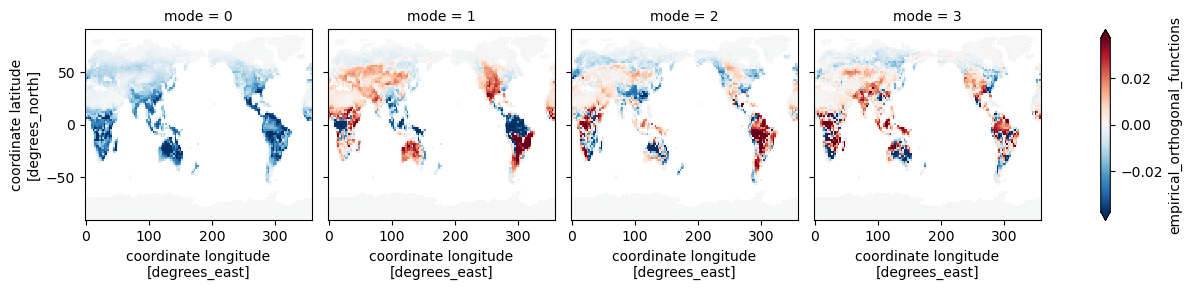

In [9]:
fhist_diff_tavg_eof["EFLX_LH_TOT_month_1"].eofs.sel(mode=slice(0,3)).plot(col='mode', robust=True)

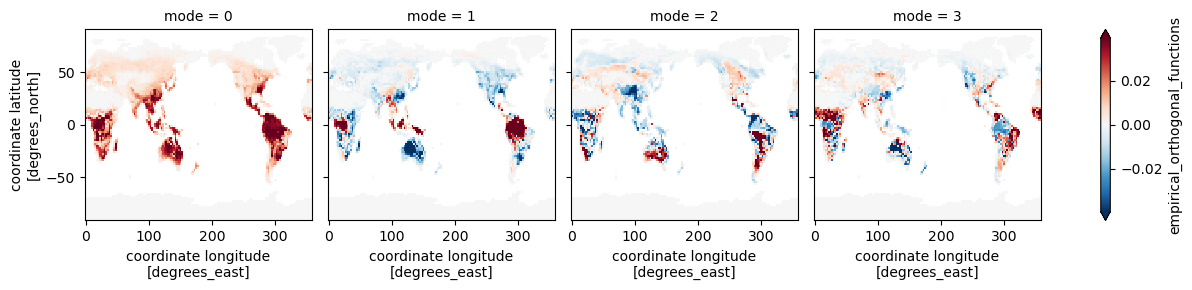

In [10]:
fhist_diff_tavg_eof["FCTR_month_1"].eofs.sel(mode=slice(0,3)).plot(col='mode', robust=True)

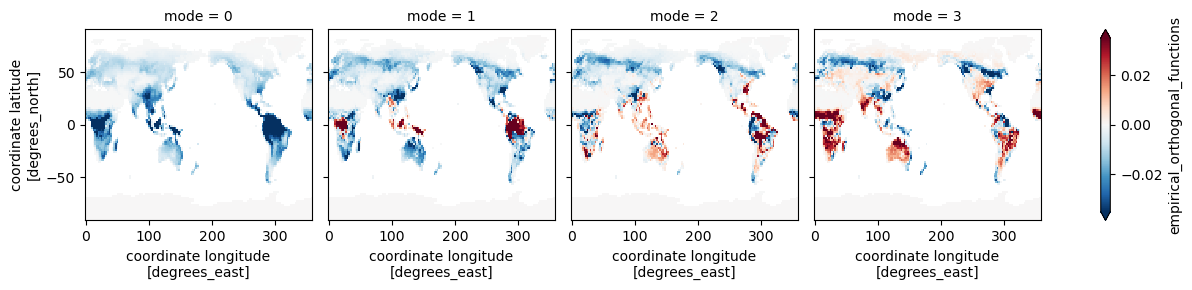

In [11]:
fhist_diff_tavg_eof["FCEV_month_1"].eofs.sel(mode=slice(0,3)).plot(col='mode', robust=True)

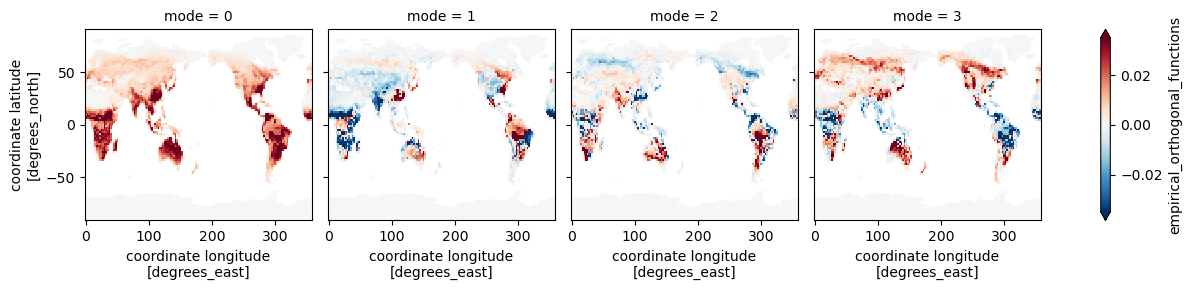

In [12]:
fhist_diff_tavg_eof["FGEV_month_1"].eofs.sel(mode=slice(0,3)).plot(col='mode', robust=True)

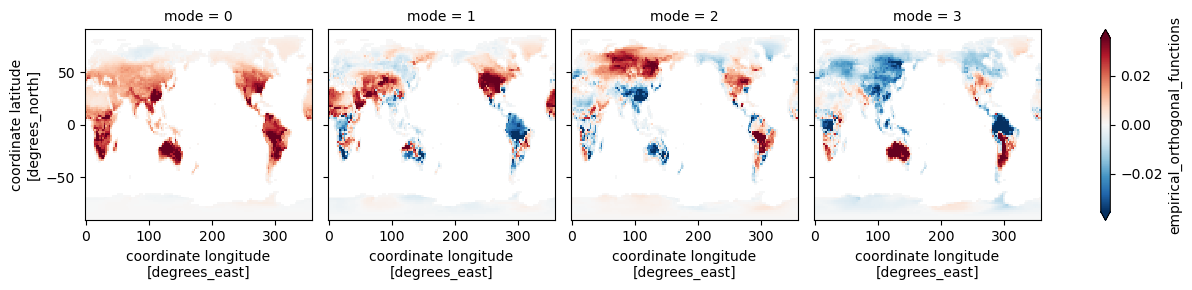

In [13]:
fhist_diff_tavg_eof["TSA_month_1"].eofs.sel(mode=slice(0,3)).plot(col='mode', robust=True)

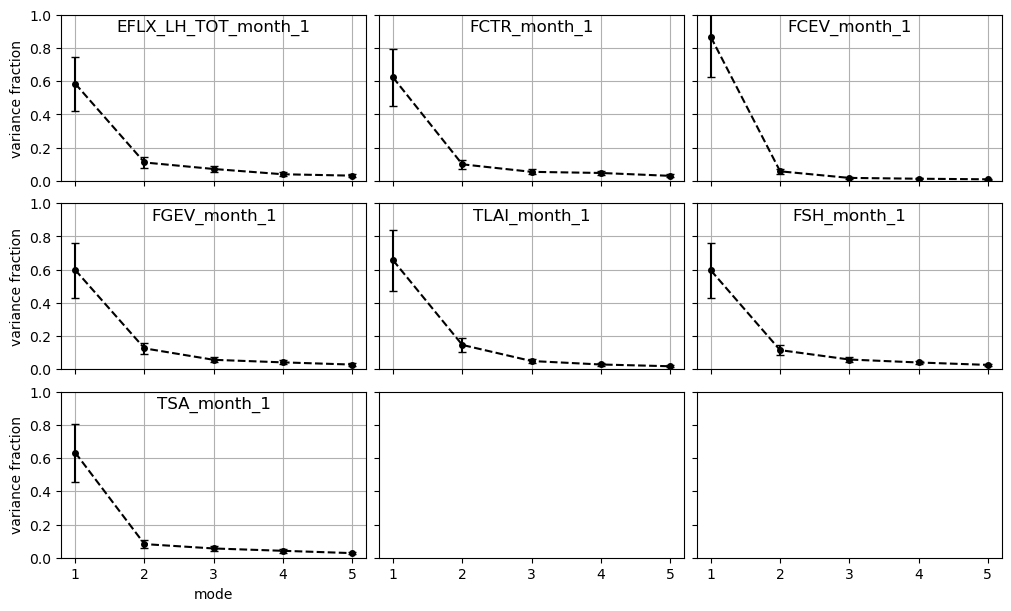

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(10, 6), sharey=True, sharex=True, layout="constrained")
for idx, v in enumerate(variables):
    ax = axes.flat[idx]
    varfrac = fhist_diff_tavg_eof[v].varfrac[:5]
    eig_err = fhist_diff_tavg_eof[v].eig_err[:5]
    ax.errorbar(np.arange(1, 6), varfrac, yerr=eig_err, fmt="--o", ms=4, c="k", capsize=3)
    # ax.set_title(v)
    ax.text(0.5, 0.9, v, fontsize=12, ha="center", transform=ax.transAxes)
    if idx % 3 == 0:
        ax.set_ylabel("variance fraction")
    if idx // 3 == 2:
        ax.set_xlabel("mode")
    ax.set_ylim(0, 1)
    ax.grid()

Text(0.5, 0, 'Mode')

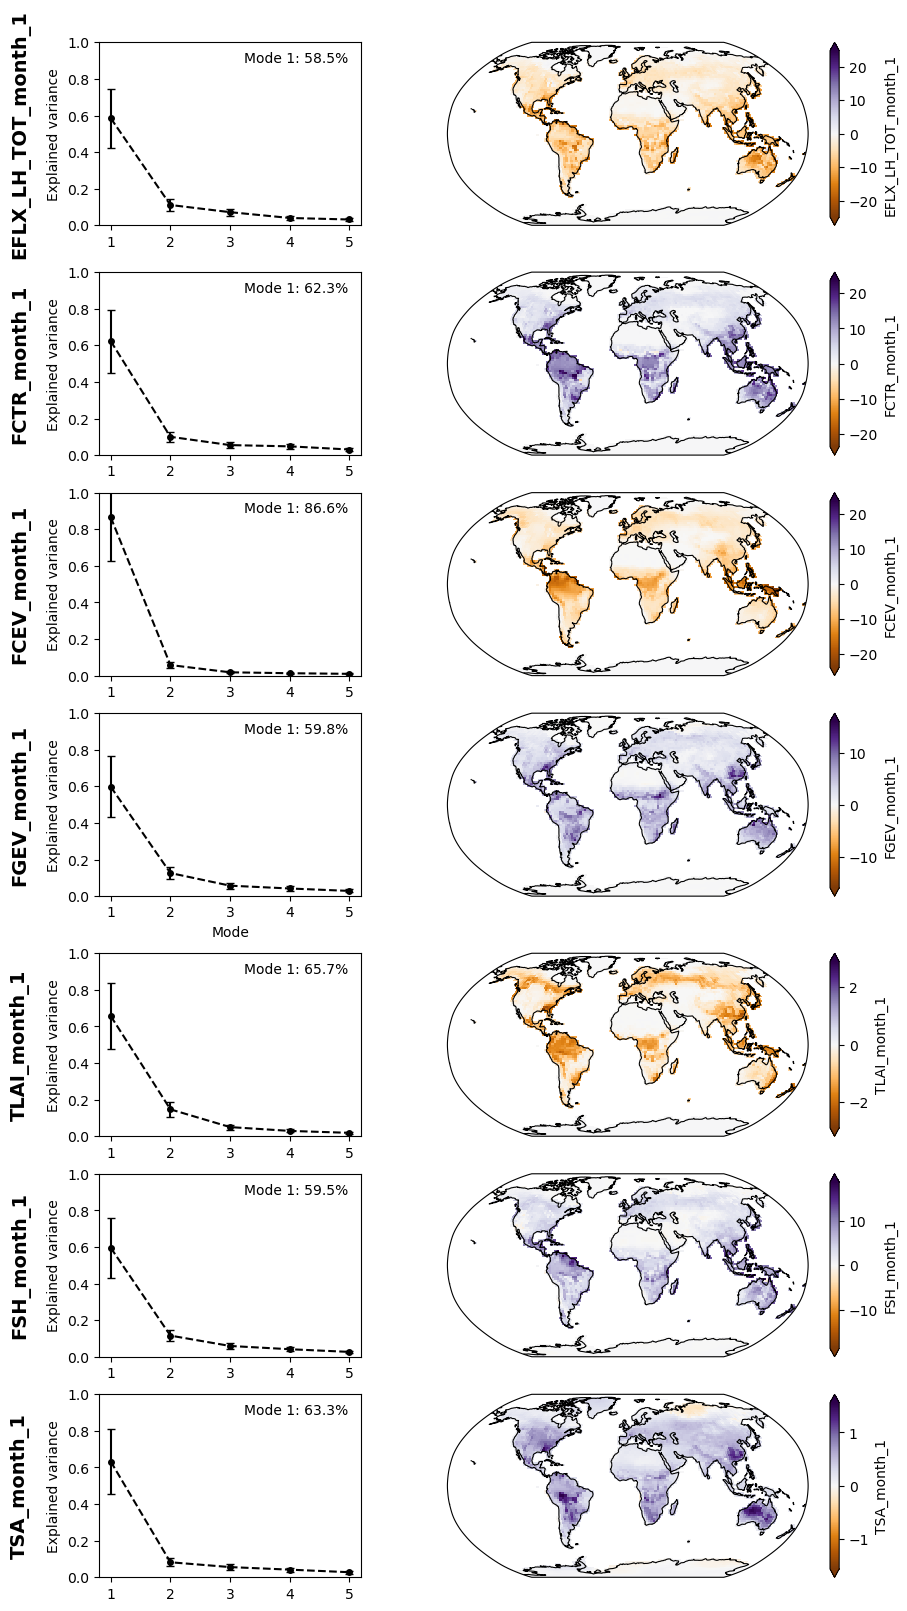

In [18]:
fig, axs = plt.subplots(7, 2, figsize=(9, 16), width_ratios=(0.6, 1), layout="constrained")
ax = axs.flatten()

for i in range(1, 14, 2):
    fig.delaxes(ax[i])
    ax[i] = fig.add_subplot(7, 2, i + 1, projection=ccrs.Robinson())

for iv, v in enumerate(variables):
    # if v in ["ETOT", "ETRN"]:
    #     factor = -1
    # else:
    #     factor = 1
    factor = 1

    varfrac = fhist_diff_tavg_eof[v].varfrac[:5]
    eig_err = fhist_diff_tavg_eof[v].eig_err[:5]

    ax[2*iv].errorbar(np.arange(1, 6), varfrac, yerr=eig_err, fmt="--o", ms=4, c="k", capsize=3)
    ax[2*iv].set_xticks([1, 2, 3, 4, 5])
    ax[2*iv].set_ylabel("Explained variance")
    ax[2*iv].set_ylim(0, 1)
    ax[2*iv].text(
        x=-0.3, y=0.5, s=v,
        ha="center", va="center", rotation=90,
        fontsize=14, fontweight="bold",
        transform=ax[2*iv].transAxes
    )

    ax[2*iv].text(
        x=0.95, y=0.95, s=f"Mode 1: {varfrac[0]*100:0.1f}%",
        ha="right", va="top",
        transform=ax[2*iv].transAxes
    )

    cmin = fhist_diff_tavg_eof[v].eofs_2sigma.sel(mode=slice(0,1)).min().values
    cmax = fhist_diff_tavg_eof[v].eofs_2sigma.sel(mode=slice(0,1)).max().values
    cabs = max([abs(cmin), abs(cmax)])

    (factor * fhist_diff_tavg_eof[v].eofs_2sigma.sel(mode=0)).plot.pcolormesh(
        ax=ax[2*iv+1], transform=ccrs.PlateCarree(),
        add_colorbar=True, vmin=-cabs, vmax=cabs, cmap="PuOr",
        cbar_kwargs={"fraction":0.025, "label":v, "extend":"both"})
    ax[2*iv+1].set_title(None)
    ax[2*iv+1].coastlines(color="k", lw=0.8)

ax[6].set_xlabel("Mode")

# fig.savefig(f"eof_all.pdf", dpi=400)

In [ ]:
from collections import namedtuple
EOFResult = namedtuple(
    "EOFResult",
    [
        "eofs",
        "eofs_2sigma",
        "varfrac",
        "eig",
        "eig_err",
        "pcs",
        "solver",
        "reconstructed",
    ]
)

fhist_time_eof = dict()
# for v in variables:
for v in ['EFLX_LH_TOT_month_1']:
    print(v)

    fhist_time_eof[v] = {}
    for i, m in enumerate(fhist[v].member):
        print(m.values)
        x = fhist[v].sel(time=slice('1995-01', '2014-12')).sel(member=m)
        climx = x.groupby('time.month')
        dmx = climx - climx.mean(dim="time")
        dmx = dmx.compute()

        solver = Eof(dmx, weights=grid.LANDAREA)
        # x = x.compute()
        # solver = Eof(x, weights=grid.LANDAREA)
        eofs = solver.eofs()
        pcs = solver.pcs()

        std_pcs = pcs.std(dim="time")
        eofs_2sigma = xr.DataArray(
            2 * eofs.values * std_pcs.values[:, None, None] / grid.LANDAREA.values[None, :, :],
            dims=eofs.dims,
            coords=eofs.coords,
            attrs=eofs.attrs
        )

        fhist_time_eof[v][i] = EOFResult(
            eofs=solver.eofs(eofscaling=0),
            eofs_2sigma=eofs_2sigma,
            varfrac=solver.varianceFraction(),
            eig=solver.eigenvalues(),
            eig_err=solver.northTest(vfscaled=True),
            pcs=solver.pcs(pcscaling=0),
            solver=solver,
            reconstructed=solver.reconstructedField(1),
        )

EFLX_LH_TOT_month_1
0
1
2
3
4
5
6
7
8
9
10
11
12
14
15
16
17
18
19
20
21
22
23
24
25
26
27


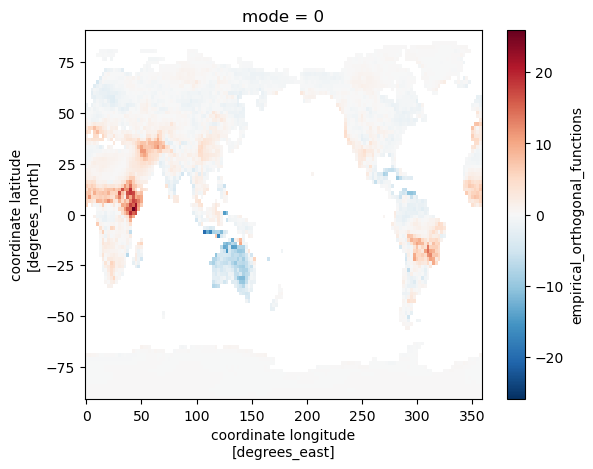

In [39]:
fhist_time_eof["EFLX_LH_TOT_month_1"][0].eofs_2sigma.sel(mode=0).plot()

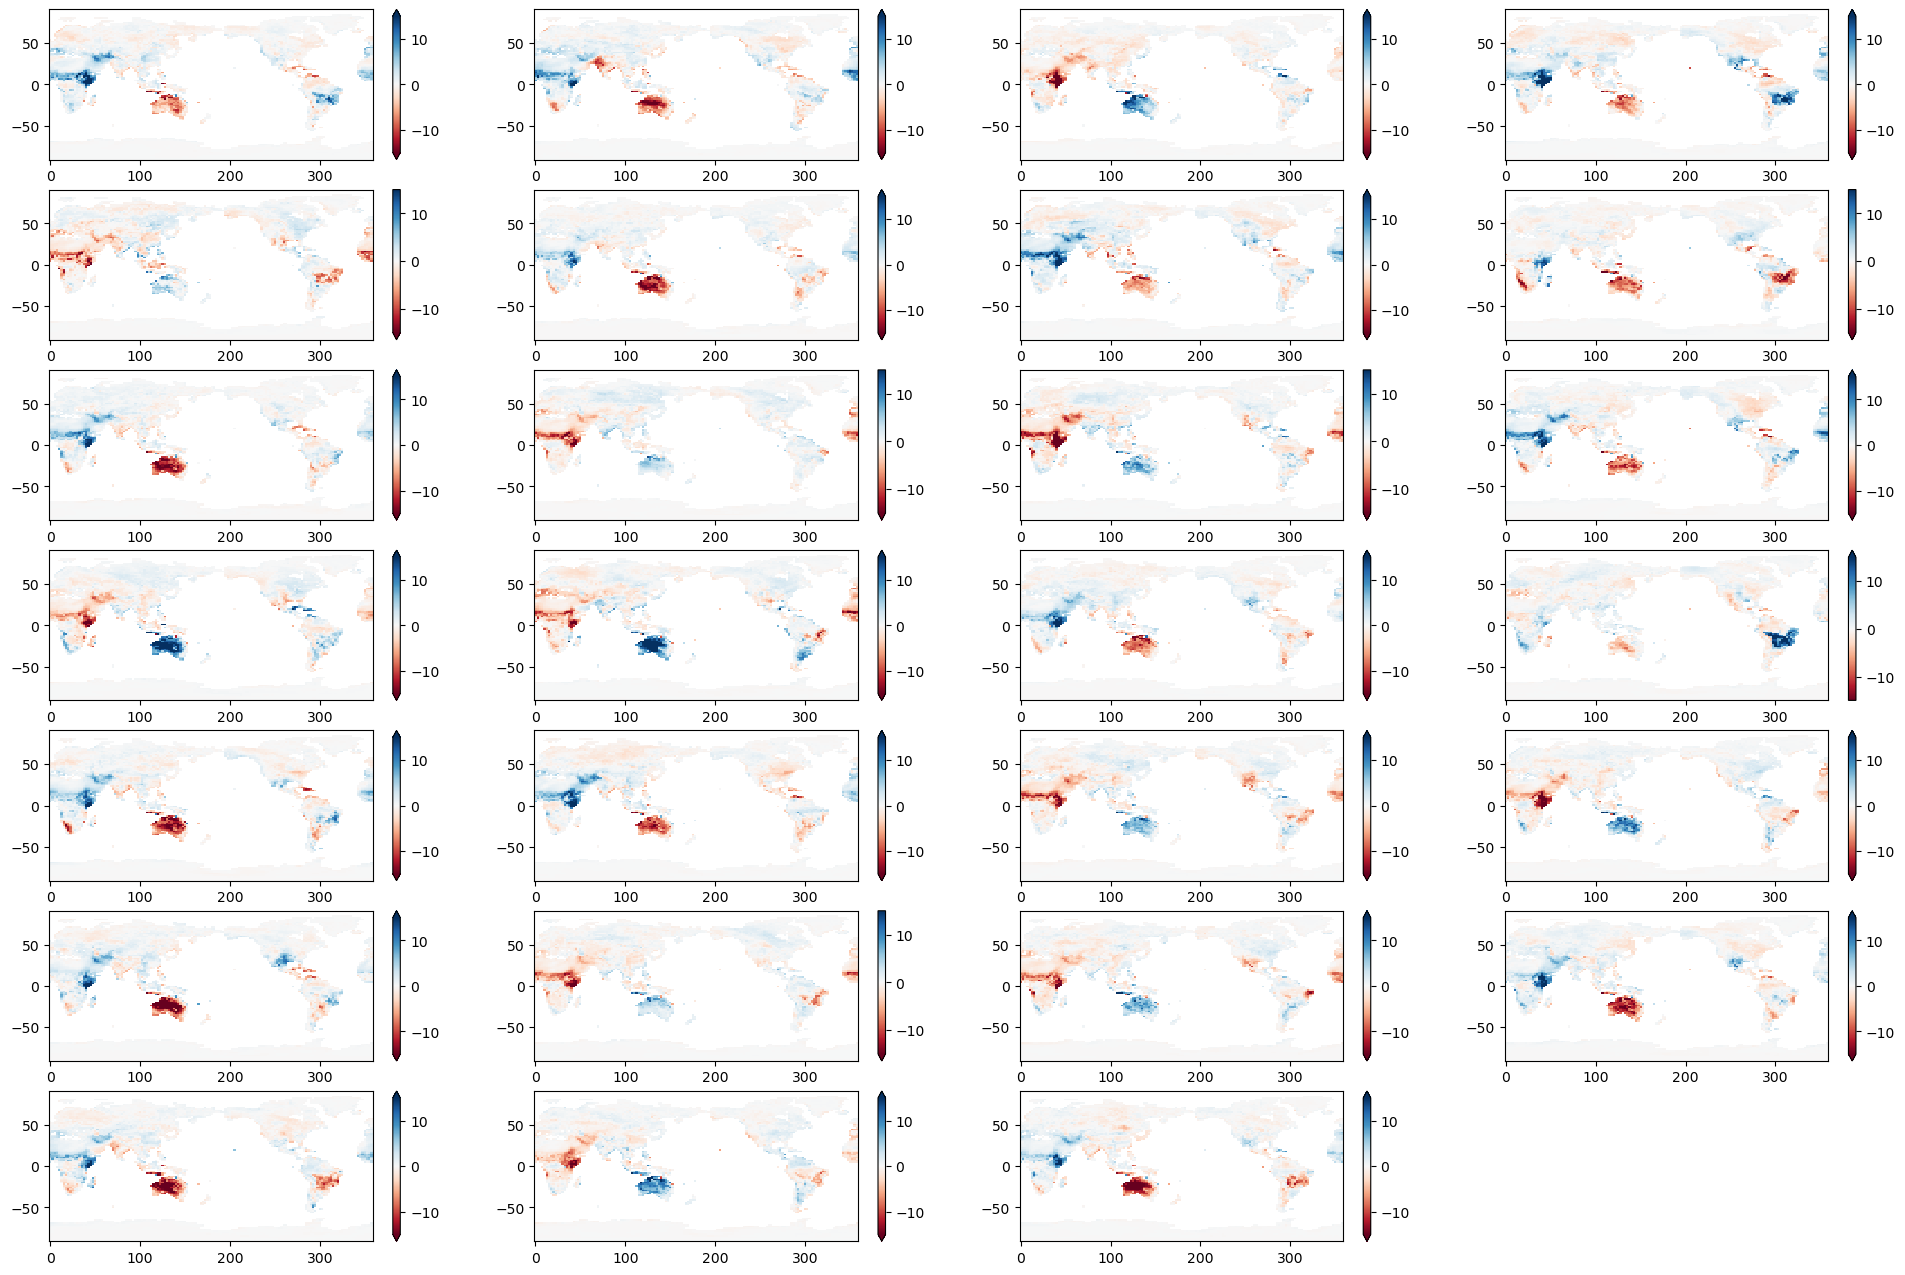

In [49]:
fig, axes = plt.subplots(7, 4, figsize=(24, 16))
axs = axes.ravel()

for i in range(27):
    fhist_time_eof["EFLX_LH_TOT_month_1"][i].eofs_2sigma.sel(mode=0).plot(ax=axs[i], vmin=-15, vmax=15, cmap='RdBu', add_labels=False)

axs[-1].remove()

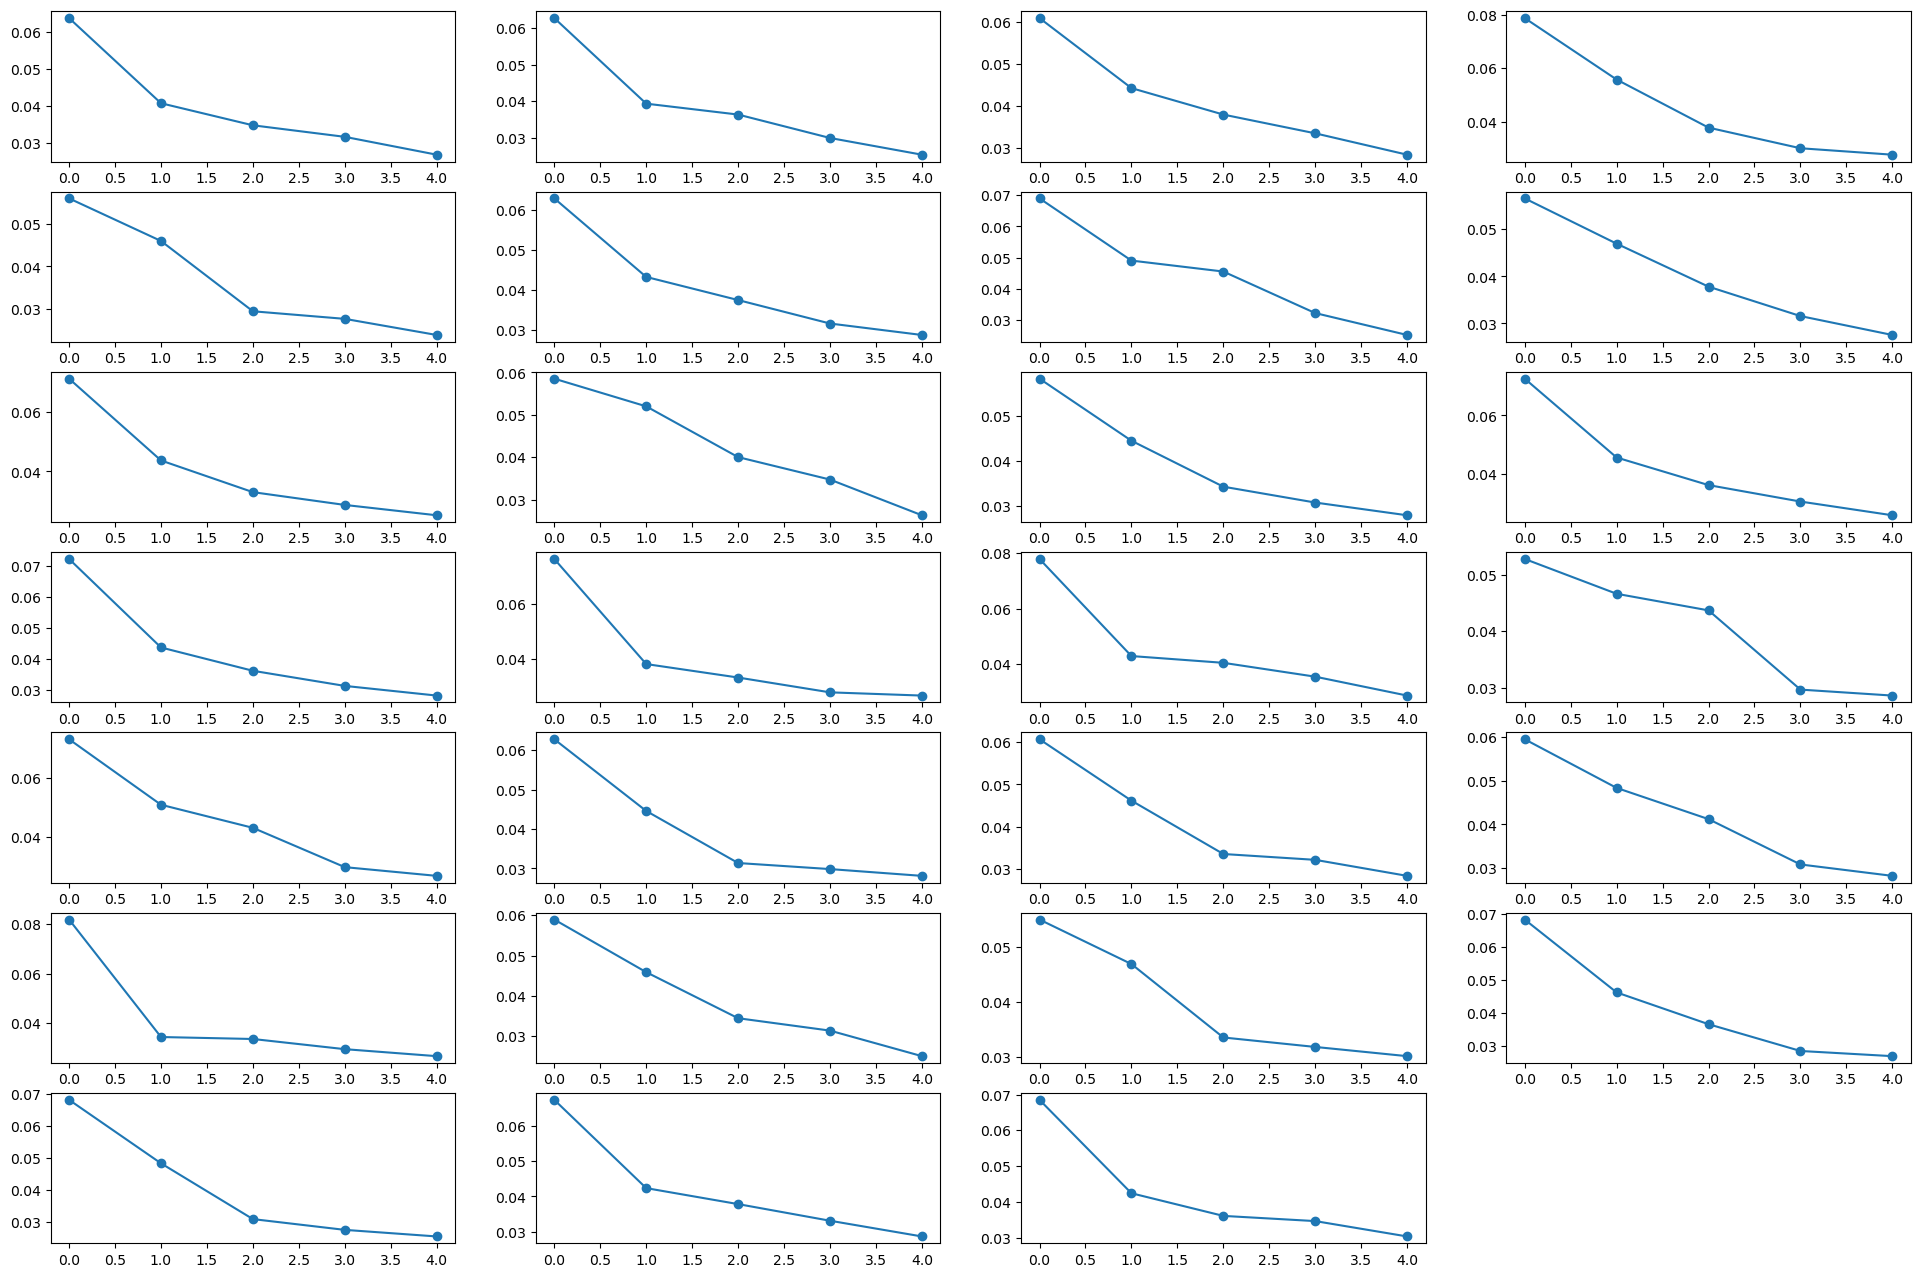

In [52]:
fig, axes = plt.subplots(7, 4, figsize=(24, 16))
axs = axes.ravel()

for i in range(27):
    fhist_time_eof["EFLX_LH_TOT_month_1"][i].varfrac.sel(mode=slice(0, 4)).plot(ax=axs[i], _labels=False, marker='o')

axs[-1].remove()

In [54]:
fhist_time_eof["EFLX_LH_TOT_month_1"][i].varfrac[:5]

<xarray.DataArray 'variance_fractions' (mode: 5)> Size: 20B
array([0.06852631, 0.04242293, 0.03609378, 0.03463986, 0.03034709],
      dtype=float32)
Coordinates:
  * mode     (mode) int64 40B 0 1 2 3 4
Attributes:
    long_name:  variance_fractions

In [55]:
fhist_diff_tavg_eof["EFLX_LH_TOT_month_1"].varfrac[:5]

<xarray.DataArray 'variance_fractions' (mode: 5)> Size: 20B
array([0.5852871 , 0.11101352, 0.07174187, 0.04002299, 0.03169488],
      dtype=float32)
Coordinates:
  * mode     (mode) int64 40B 0 1 2 3 4
Attributes:
    long_name:  variance_fractions